In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns
import os
import pickle
import gc


from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None) 

In [4]:
# Pathsクラス
class Paths:
    p = "/Users/shirokoshikentaro/Downloads/house-prices-advanced-regression-techniques/"
    train = p + "train.csv"
    test = p + "test.csv"
    sample = p + "sample_submission.csv"

In [5]:
# === データ読み込み ===
print("データ読み込み中...")
train_raw = pd.read_csv(Paths.train)
test_raw = pd.read_csv(Paths.test)

データ読み込み中...


In [6]:
train_raw.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
import logging
from time import time

import pandas as pd


def check_df(df, columns=None, show_values_limit=10):
    """
    DataFrameの各列の情報（データ型、NaN数、ユニーク数、ユニーク値）を一覧表示します

    Parameters:
    - df: 対象のDataFrame
    - columns: 対象の列 (list)。Noneのときは全列
    - show_values_limit: ユニーク値を表示する最大数。これを超える列は「多すぎる」と表示されます

    Returns:
    - info_df: 各列の情報をまとめたDataFrame
    """
    if columns is not None:
        df = df[columns]

    type_series = df.dtypes
    nan_count_series = df.isnull().sum()
    nunique_series = df.nunique()

    unique_values = {}
    for col in df.columns:
        if nunique_series[col] <= show_values_limit:
            unique_values[col] = df[col].unique().tolist()
        else:
            unique_values[col] = f"> {show_values_limit} unique values"

    info_df = pd.DataFrame(
        {
            "dtypes": type_series.astype(str),
            "NaN Count": nan_count_series,
            "Nunique": nunique_series,
            "Unique Values": pd.Series(unique_values),
        }
    )

    info_df = info_df.reset_index().rename(columns={"index": "Column"})

    return info_df


def elapsed_time(start):
    """経過時間を表示する関数
    Args:
        start (float): 開始時刻
    """
    elapsed = int(time() - start)
    minutes, elapsed = divmod(elapsed, 60)
    hours, minutes = divmod(minutes, 60)
    seconds = elapsed % 60
    return hours, minutes, seconds


def setup_logger(name="run", level=logging.INFO):
    """ロガーを設定する関数
    Args:
        name (str): ロガーの名前
        level (int): ログレベル
    Returns:
        logging.Logger: 設定されたロガー
    """
    logger = logging.getLogger(name)
    logger.setLevel(level)
    logger.propagate = False

    if not logger.handlers:
        # コンソール出力
        stream_handler = logging.StreamHandler()
        formatter = logging.Formatter(
            "%(asctime)s - %(message)s",
            datefmt="%Y-%m-%d %H:%M:%S",
        )
        stream_handler.setFormatter(formatter)
        logger.addHandler(stream_handler)
        # ファイル出力
        log_file = f"{name}.log"
        file_handler = logging.FileHandler(log_file, encoding="utf-8")
        file_handler.setFormatter(formatter)
        logger.addHandler(file_handler)

    return logger

In [8]:
check_df(train_raw)

,Column,dtypes,NaN Count,Nunique,Unique Values
0,Id,int64,0,1460,> 10 unique values
1,MSSubClass,int64,0,15,> 10 unique values
2,MSZoning,object,0,5,"[RL, RM, C (all), FV, RH]"
3,LotFrontage,float64,259,110,> 10 unique values
4,LotArea,int64,0,1073,> 10 unique values
5,Street,object,0,2,"[Pave, Grvl]"
6,Alley,object,1369,2,"[nan, Grvl, Pave]"
7,LotShape,object,0,4,"[Reg, IR1, IR2, IR3]"
8,LandContour,object,0,4,"[Lvl, Bnk, Low, HLS]"
9,Utilities,object,0,2,"[AllPub, NoSeWa]"


In [9]:
# 数値型変数を抽出
num_features = train_raw.select_dtypes(include=[np.number]).columns.tolist()
num_features

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

In [10]:
print(type(plt))

<class 'module'>


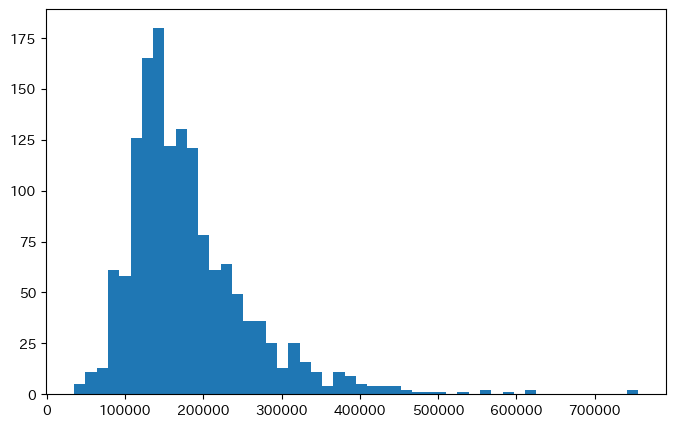

In [11]:
target_col = "SalePrice"

plt.figure(figsize=(8, 5))
plt.hist(train_raw[target_col], bins=50)
plt.show()

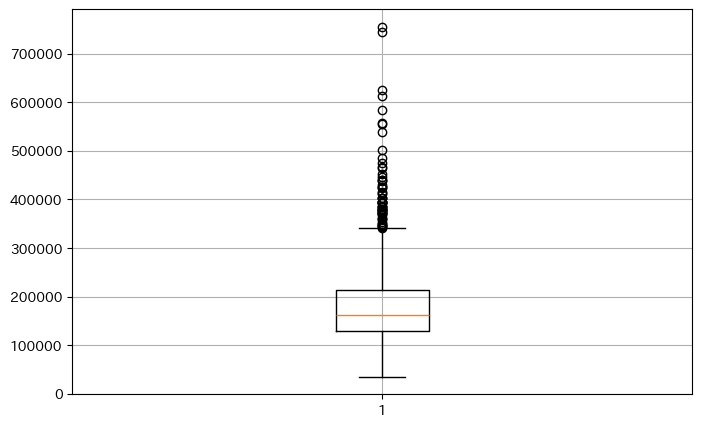

In [12]:
plt.figure(figsize=(8, 5))
plt.boxplot(train_raw[target_col])
plt.grid()
plt.show()

In [13]:
train_raw[["LotArea", "YearBuilt", "YearRemodAdd",
    "GrLivArea", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF",
    "FullBath", "BedroomAbvGr", "TotRmsAbvGrd",
    "GarageCars", "GarageArea",
    "OverallQual", "OverallCond", "Neighborhood", "BldgType", "HouseStyle",
    "MSZoning", "Foundation", "GarageType"
]].isnull().sum()

LotArea          0
YearBuilt        0
YearRemodAdd     0
GrLivArea        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
FullBath         0
BedroomAbvGr     0
TotRmsAbvGrd     0
GarageCars       0
GarageArea       0
OverallQual      0
OverallCond      0
Neighborhood     0
BldgType         0
HouseStyle       0
MSZoning         0
Foundation       0
GarageType      81
dtype: int64

In [2]:
# === 特徴量定義 ===
numeric_features = [
    "LotArea", "YearBuilt", "YearRemodAdd",
    "GrLivArea", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF",
    "FullBath", "BedroomAbvGr", "TotRmsAbvGrd",
    "GarageCars", "GarageArea",
    "OverallQual", "OverallCond",
]

categorical_features = [
    "Neighborhood", "BldgType", "HouseStyle",
    "MSZoning", "Foundation", "GarageType"
]

features = numeric_features + categorical_features

print(f"使用する特徴量: {len(features)}個")

使用する特徴量: 20個


In [15]:
# === 新しいDataFrameを作成（エンコーディング用） ===
print("\n特徴量を抽出して新しいDataFrameを作成...")

# trainとtestから特徴量を取得
train_features = train_raw[features].copy()
test_features = test_raw[features].copy()


特徴量を抽出して新しいDataFrameを作成...


In [16]:
# === 欠損値処理 ===
print("欠損値処理中...")
for col in numeric_features:
    train_features[col] = train_features[col].fillna(0)
    test_features[col] = test_features[col].fillna(0)

for col in categorical_features:
    train_features[col] = train_features[col].fillna("None")
    test_features[col] = test_features[col].fillna("None")

欠損値処理中...


In [ ]:
# === カテゴリ変数のエンコーディング（確実な方法） ===
print("\nカテゴリ変数をエンコーディング中...")

# エンコーディング済みのデータを格納する辞書
train_encoded = {}
test_encoded = {}

# 数値特徴量はそのままコピー
for col in numeric_features:
    train_encoded[col] = train_features[col].values
    test_encoded[col] = test_features[col].values

# カテゴリ特徴量をエンコーディング
for col in categorical_features:
    print(f"エンコーディング: {col}")
    
    # trainとtestを結合
    all_data = pd.concat([
        train_features[col].astype(str), 
        test_features[col].astype(str)
    ], axis=0)
    
    # LabelEncoderで学習
    le = LabelEncoder()
    le.fit(all_data)
    
    # trainとtestを変換
    train_encoded[col] = le.transform(train_features[col].astype(str))
    test_encoded[col] = le.transform(test_features[col].astype(str))

    


カテゴリ変数をエンコーディング中...


NameError: name 'numeric_features' is not defined

In [ ]:
# === 新しいDataFrameを作成 ===
print("\n新しいDataFrameを作成中...")
X_train = pd.DataFrame(train_encoded, columns=features)
X_test = pd.DataFrame(test_encoded, columns=features)
y_train = train_raw["SalePrice"].copy()


新しいDataFrameを作成中...


NameError: name 'pd' is not defined

In [19]:
# === 確認 ===
print("\n" + "=" * 50)
print("データ準備完了")
print("=" * 50)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")

print("\nX_train dtypes:")
print(X_train.dtypes.value_counts())

print("\nX_test dtypes:")
print(X_test.dtypes.value_counts())

# object型が残っているかチェック
if 'object' in X_train.dtypes.values or 'object' in X_test.dtypes.values:
    print("\n⚠️ 警告: まだobject型があります")
    print("X_train object:", X_train.select_dtypes(include=['object']).columns.tolist())
    print("X_test object:", X_test.select_dtypes(include=['object']).columns.tolist())
else:
    print("\n✅ 全て数値型です！")


データ準備完了
X_train shape: (1460, 20)
X_test shape: (1459, 20)
y_train shape: (1460,)

X_train dtypes:
int64    20
Name: count, dtype: int64

X_test dtypes:
int64      17
float64     3
Name: count, dtype: int64

✅ 全て数値型です！


In [20]:
# === モデルパラメータ ===
params = {
    "boosting_type": "gbdt",
    "objective": "regression",
    "metric": "rmse",
    "num_leaves": 16,
    "learning_rate": 0.1,
    "n_estimators": 10000,
    "random_state": 123,
    "verbose": -1,
}

In [1]:
# === CV実行 ===
print("\n" + "=" * 50)
print("Cross Validation 開始")
print("=" * 50)

n_splits = 5
cv = KFold(n_splits=n_splits, shuffle=True, random_state=123)
metrics = []
imp = pd.DataFrame()

for nfold, (train_index, valid_index) in enumerate(cv.split(X_train, y_train)):
    print(f"\n{'=' * 10} Fold {nfold} {'=' * 10}")
    X_tr, y_tr = X_train.iloc[train_index], y_train.iloc[train_index]
    X_val, y_val = X_train.iloc[valid_index], y_train.iloc[valid_index]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(0),
        ],
    )

    y_tr_pred = model.predict(X_tr)
    y_val_pred = model.predict(X_val)

    tr_rmse = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
    metrics.append([nfold, tr_rmse, val_rmse])

    _imp = pd.DataFrame(
        {
            "col": X_train.columns,
            "imp": model.feature_importances_,
            "nfold": nfold
        }
    )

    imp = pd.concat([imp, _imp], ignore_index=True) 


    

    print(f"Train RMSE: {tr_rmse:.5f}, Valid RMSE: {val_rmse:.5f}")


Cross Validation 開始


NameError: name 'KFold' is not defined

In [22]:
imp = imp.groupby("col")["imp"].agg(["mean","std"])
imp.columns = ["imp","imp_std"]

imp_df = imp.sort_values(by="imp",ascending=False)

imp_df.head(30)

,imp,imp_std
col,,
LotArea,570.4,521.199386
GarageArea,554.2,502.758093
1stFlrSF,519.8,478.025836
GrLivArea,504.0,386.855916
TotalBsmtSF,470.8,385.289112
YearBuilt,227.0,194.852508
2ndFlrSF,206.2,179.268514
YearRemodAdd,197.6,162.878175
Neighborhood,177.6,135.737983


In [23]:
# === CVスコア ===
metrics_array = np.array(metrics)
print("\n" + "=" * 50)
print("CV結果")
print("=" * 50)
print("[CV] train: {:.5f}±{:.5f}, valid: {:.5f}±{:.5f}".format(
    metrics_array[:,1].mean(), metrics_array[:,1].std(),
    metrics_array[:,2].mean(), metrics_array[:,2].std(),
))
print("=" * 50)


CV結果
[CV] train: 13283.75876±7489.61064, valid: 28853.25012±2789.42756


In [ ]:
# === testデータで予測 ===
print("\n" + "=" * 50)
print("Test予測")
print("=" * 50)

print("予測実行中...")
y_test_pred = model.predict(X_test)

# === 提出ファイル ===
df_submit = pd.DataFrame({
    "Id": test_raw["Id"],
    "SalePrice": y_test_pred,
})

print("\n提出ファイル:")
print(df_submit.head(10))
print(f"\nデータ数: {len(df_submit)}")
print(f"予測価格の範囲: ${df_submit['SalePrice'].min():,.0f} ~ ${df_submit['SalePrice'].max():,.0f}")
print(f"予測価格の平均: ${df_submit['SalePrice'].mean():,.0f}")


Test予測
予測実行中...

提出ファイル:
     Id      SalePrice
0  1461  138933.237045
1  1462  154448.114778
2  1463  169803.476088
3  1464  182097.969639
4  1465  197502.864980
5  1466  185860.409176
6  1467  172596.002403
7  1468  176331.508978
8  1469  177242.326906
9  1470  118317.426657

データ数: 1459
予測価格の範囲: $30,221 ~ $551,294
予測価格の平均: $179,143


In [25]:
# 保存
df_submit.to_csv("submission.csv", index=False)
print("\n✅ submission.csv を保存しました！")


✅ submission.csv を保存しました！


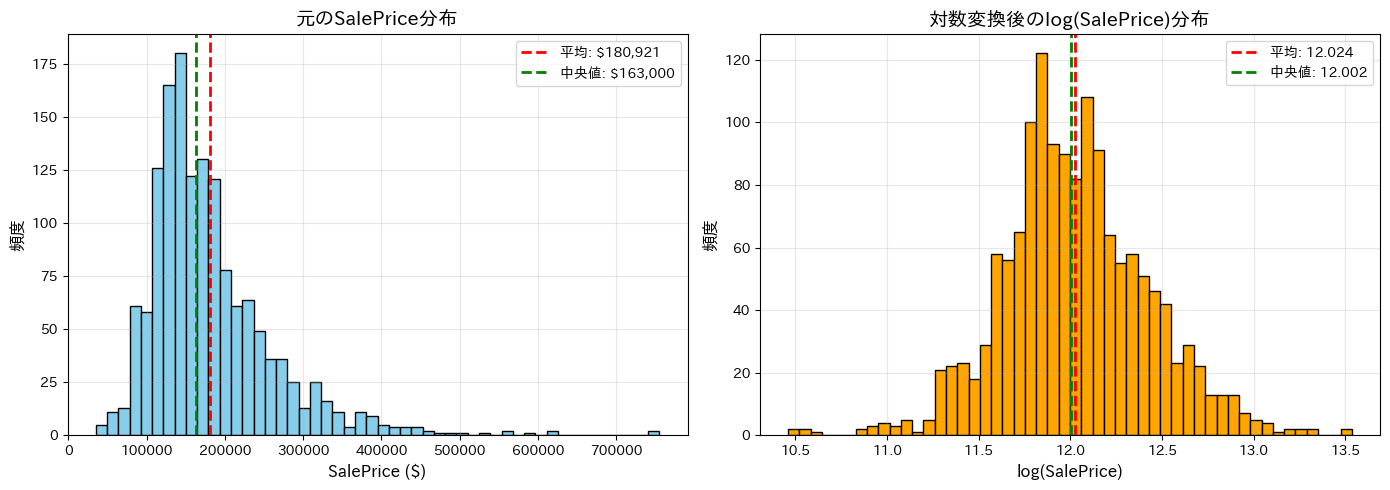

In [26]:
# データ読み込み
train = pd.read_csv(Paths.train)

# 元の価格と対数変換後の価格
original_price = train["SalePrice"]
log_price = np.log1p(train["SalePrice"])

# ヒストグラムを作成
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左側: 元の価格
axes[0].hist(original_price, bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('元のSalePrice分布', fontsize=14, fontweight='bold')
axes[0].set_xlabel('SalePrice ($)', fontsize=12)
axes[0].set_ylabel('頻度', fontsize=12)
axes[0].axvline(original_price.mean(), color='red', linestyle='--', linewidth=2, label=f'平均: ${original_price.mean():,.0f}')
axes[0].axvline(original_price.median(), color='green', linestyle='--', linewidth=2, label=f'中央値: ${original_price.median():,.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 右側: 対数変換後
axes[1].hist(log_price, bins=50, edgecolor='black', color='orange')
axes[1].set_title('対数変換後のlog(SalePrice)分布', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(SalePrice)', fontsize=12)
axes[1].set_ylabel('頻度', fontsize=12)
axes[1].axvline(log_price.mean(), color='red', linestyle='--', linewidth=2, label=f'平均: {log_price.mean():.3f}')
axes[1].axvline(log_price.median(), color='green', linestyle='--', linewidth=2, label=f'中央値: {log_price.median():.3f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()